Feature Selection = **choosing the most relevant features** and removing irrelevant or redundant ones to improve:

* Model performance
* Training speed
* Interpretability
* Overfitting reduction

There are **3 main categories** (plus some advanced ones):

---

# 1️⃣ Filter Methods (Statistical Methods)

👉 Select features **before training the model**
👉 Based on statistical tests
👉 Fast and model-independent

---

## 🔹 A. Variance Threshold

* Remove features with low variance
* Idea: If a feature barely changes → not useful

Formula:
[
Var(X) = \frac{1}{n} \sum (x_i - \mu)^2
]

Used when:

* Removing constant / near-constant columns

---

## 🔹 B. Correlation (Pearson)

Used for:

* Regression problems

Formula:
[
r = \frac{Cov(X,Y)}{\sigma_X \sigma_Y}
]

Keep features with high correlation to target
Remove features highly correlated with each other (multicollinearity)

---

## 🔹 C. Chi-Square Test

Used for:

* Categorical features
* Classification

Measures dependency between feature and target

Higher χ² → More important feature

---

## 🔹 D. ANOVA (F-test)

Used for:

* Numerical feature
* Categorical target

Measures variance between groups

Higher F-score → More important

---

| Feature Type | Target Type | Can Use ANOVA?      |
| ------------ | ----------- | ------------------- |
| Numerical    | Categorical | ✅ Yes               |
| Categorical  | Categorical | ❌ (use Chi-Square)  |
| Numerical    | Numerical   | ❌ (use correlation) |



## 🔹 E. Mutual Information

Works for:

* Classification & regression

Measures how much information feature gives about target

[
MI(X,Y) = \sum p(x,y)\log\frac{p(x,y)}{p(x)p(y)}
]

Higher MI → More useful

---

## 🔹 F. Information Gain

Used in:

* Decision Trees

Based on entropy

[
Entropy = -\sum p \log p
]

---

# 2️⃣ Wrapper Methods

👉 Use a ML model to evaluate feature subsets
👉 More accurate but computationally expensive

---

## 🔹 A. Forward Selection

Start with no features
Add one feature at a time
Keep the best improvement

---

## 🔹 B. Backward Elimination

Start with all features
Remove one at a time
Remove least useful

Often uses:

* p-value threshold (like 0.05)

---

## 🔹 C. Stepwise Selection

Combination of:

* Forward + Backward

---

## 🔹 D. Recursive Feature Elimination (RFE)

1. Train model
2. Rank features
3. Remove weakest
4. Repeat

Works well with:

* Linear models
* SVM
* Random Forest

---

# 3️⃣ Embedded Methods

👉 Feature selection happens **during model training**

---

## 🔹 A. Lasso (L1 Regularization)

[
Loss + \lambda \sum |w|
]

L1 pushes some coefficients to **zero**
Zero coefficient → feature removed

---

## 🔹 B. Ridge (L2)

[
Loss + \lambda \sum w^2
]

Does NOT remove features
Just shrinks them

---

## 🔹 C. Elastic Net

Combination of:

* L1 + L2

---

## 🔹 D. Tree-Based Feature Importance

Models:

* Random Forest
* Gradient Boosting
* XGBoost

Importance based on:

* Gini importance
* Information gain

---

# 4️⃣ Advanced / Modern Techniques

---

## 🔹 A. Boruta

Wrapper over Random Forest
Keeps only statistically significant features

---

## 🔹 B. SHAP-based Selection

Uses SHAP values
Select features with high average impact

---

## 🔹 C. Permutation Importance

1. Shuffle one feature
2. Measure drop in accuracy
3. Big drop → Important feature

---

## 🔹 D. Genetic Algorithms

Search optimal feature subset using evolution concepts

---

# 5️⃣ Dimensionality Reduction (Related but Different ⚠️)

Not exactly feature selection, but often confused:

* PCA
* LDA
* t-SNE
* Autoencoders

These **create new features**, not select existing ones.

---

# 🔥 Quick Comparison

| Type     | Speed  | Accuracy | Overfitting Risk | Example     |
| -------- | ------ | -------- | ---------------- | ----------- |
| Filter   | Fast   | Medium   | Low              | Correlation |
| Wrapper  | Slow   | High     | Medium           | RFE         |
| Embedded | Medium | High     | Low              | Lasso       |

---



In [1]:
import pandas as pd

# compute chi-squared stats between each non-negative feature and class.

This score should be used to evaluate categorical variables in a classification task.
This score can be used to select the n_features features with the highest values for the test chi-squared statistic from X, which must contain only non-negative features such as booleans or frequencies (e.g., term counts in document classification), relative to the classes.

Recall that the chi-square test measures dependence between stochastic variables, so using this function “weeds out” the features that are the most likely to be independent of class and therefore irrelevant for classification. The Chi Square statistic is commonly used for testing relationships between categorical variables.

It compares the observed distribution of the different classes of target Y among the different categories of the feature, against the expected distribution of the target classes, regardless of the feature categories.


After applying the chi-sq , we got array of 2 values F value and p value , F value is higher and p value is lower , then feature is important.

In [ ]:
df= pd.read_csv('data/mobile_dataset.csv')
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


**Univariate Selection**

In [6]:
X = df.iloc[:,:-1]
y = df['price_range']

In [7]:
X.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0


In [8]:
y.head()

0    1
1    2
2    2
3    2
4    1
Name: price_range, dtype: int64

In [11]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

In [12]:
df.shape

(2000, 21)

In [13]:
# Apply SelectKBest
ordered_rank_feature = SelectKBest(score_func=chi2,k=20)
ordered_feature = ordered_rank_feature.fit(X,y)

In [ ]:
dfscores = pd.DataFrame(ordered_feature.scores_,columns=['Scores'])


#  Dropping constant features
In this step we will be removing the features which have constant features which are actually not important for solving the problem statement 

In [1]:
import pandas as pd 

data = pd.DataFrame({"A":[1,2,4,1,2,4], 
                    "B":[4,5,6,7,8,9], 
                    "C":[0,0,0,0,0,0],
                    "D":[1,1,1,1,1,1]})

In [2]:
data.head()

,A,B,C,D
0,1,4,0,1
1,2,5,0,1
2,4,6,0,1
3,1,7,0,1
4,2,8,0,1


## Variance Threshold
Feature selector that removes all low-variance features.

This feature selection algorithm looks only at the features (X), not the desired outputs (y), and can thus be used for unsupervised learning.

In [3]:
from sklearn.feature_selection import VarianceThreshold

var_thres = VarianceThreshold(threshold=0)
var_thres.fit(data)

,"threshold threshold: float, default=0Features with a training-set variance lower than this threshold willbe removed. The default is to keep all features with non-zero variance,i.e. remove the features that have the same value in all samples.",0


In [4]:
var_thres.get_support()

array([ True,  True, False, False])

In [5]:
data.columns[var_thres.get_support()]

Index(['A', 'B'], dtype='str')

In [6]:
constant_columns = [column for column in data.columns if column not in data.columns[var_thres.get_support()]]
print(len(constant_columns))

2


In [7]:
for feature in constant_columns:
    print(feature)

C
D


In [8]:
data.drop(constant_columns,axis=1)

,A,B
0,1,4
1,2,5
2,4,6
3,1,7
4,2,8
5,4,9


# With Correlation
In this step we will be removing the features which are highly correlated


In [10]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
data = load_breast_cancer()

In [14]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

In [15]:
data.feature_names

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [16]:
data.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

In [19]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop('target',axis=1),df['target'],test_size=0.3,random_state=42)

In [25]:
X_train.shape,X_test.shape

((398, 30), (171, 30))

In [28]:
X_train.corr().columns

Index(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error', 'fractal dimension error',
       'worst radius', 'worst texture', 'worst perimeter', 'worst area',
       'worst smoothness', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry', 'worst fractal dimension'],
      dtype='str')

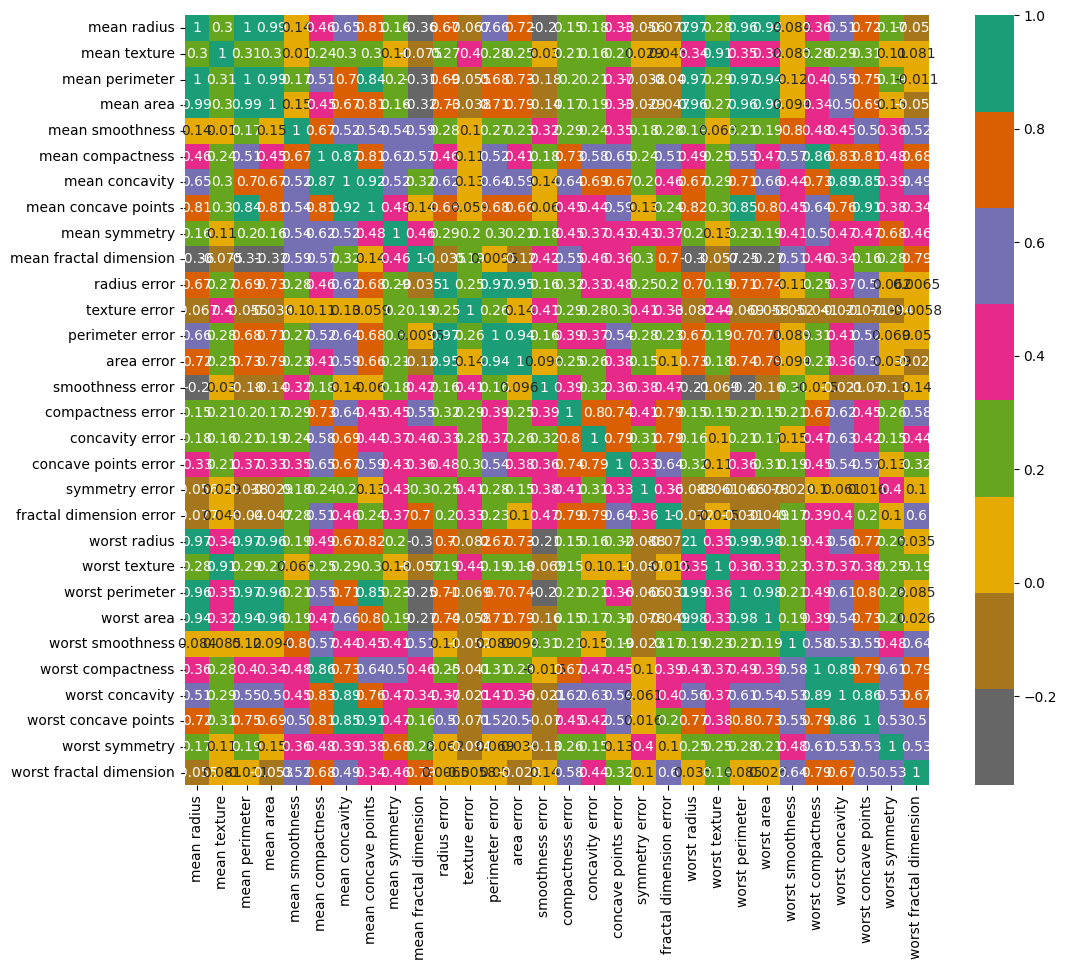

In [27]:
import seaborn as sns
# Using Pearson Correlation
plt.figure(figsize=(12,10))
cor = X_train.corr()
sns.heatmap(cor,annot=True,cmap=plt.cm.Dark2_r)
plt.show()

In [29]:
def correlation(dataset,threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [30]:
corr_feature = correlation(X_train,0.7)
len(set(corr_feature))

20

In [31]:
corr_feature

{'area error',
 'compactness error',
 'concave points error',
 'concavity error',
 'fractal dimension error',
 'mean area',
 'mean concave points',
 'mean concavity',
 'mean perimeter',
 'perimeter error',
 'radius error',
 'worst area',
 'worst compactness',
 'worst concave points',
 'worst concavity',
 'worst fractal dimension',
 'worst perimeter',
 'worst radius',
 'worst smoothness',
 'worst texture'}

In [32]:
X_train.drop(corr_feature,axis=1)
X_test.drop(corr_feature,axis=1)

,mean radius,mean texture,mean smoothness,mean compactness,mean symmetry,mean fractal dimension,texture error,smoothness error,symmetry error,worst symmetry
204,12.470,18.60,0.09965,0.10580,0.1925,0.06373,1.0440,0.006953,0.01782,0.3014
70,18.940,21.31,0.09009,0.10290,0.1582,0.05461,0.7975,0.004444,0.01386,0.2551
131,15.460,19.48,0.10920,0.12230,0.1931,0.05796,0.7859,0.006240,0.01397,0.2837
431,12.400,17.68,0.10540,0.13160,0.1811,0.07102,1.4600,0.010000,0.02187,0.2556
540,11.540,14.44,0.09984,0.11200,0.1818,0.06782,1.7680,0.012150,0.01840,0.2329
...,...,...,...,...,...,...,...,...,...,...
69,12.780,16.49,0.09831,0.05234,0.1590,0.05653,0.8732,0.007962,0.02254,0.2383
542,14.740,25.42,0.08275,0.07214,0.1840,0.05680,1.3850,0.004775,0.01870,0.2722
176,9.904,18.06,0.09699,0.12940,0.1669,0.08116,2.2610,0.012860,0.03880,0.2614
501,13.820,24.49,0.11620,0.16810,0.2275,0.07237,1.5280,0.009680,0.02434,0.3651


# Mutual Information

MI Estimate mutual information for a discrete target variable.

Mutual information (MI) between two random variables is a non-negative value, which measures the dependency between the variables. It is equal to zero if and only if two random variables are independent, and higher values mean higher dependency.

The function relies on nonparametric methods based on entropy estimation from k-nearest neighbors distances.

Inshort

A quantity called mutual information measures the amount of information one can obtain from one random variable given another.



## classification problem

In [33]:
import pandas as pd

In [34]:
df=pd.read_csv('https://gist.githubusercontent.com/tijptjik/9408623/raw/b237fa5848349a14a14e5d4107dc7897c21951f5/wine.csv')
df.head()

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [35]:
df["Wine"].unique()

array([1, 2, 3])

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid.phenols  178 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD                    178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [37]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.drop('Wine',axis=1),df['Wine'],test_size=0.3,random_state=42)

In [38]:
X_train.shape

(124, 13)

In [42]:
y_train.shape

(124,)

In [40]:
X_train.head()

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
138,13.49,3.59,2.19,19.5,88,1.62,0.48,0.58,0.88,5.70,0.81,1.82,580
104,12.51,1.73,1.98,20.5,85,2.20,1.92,0.32,1.48,2.94,1.04,3.57,672
78,12.33,0.99,1.95,14.8,136,1.90,1.85,0.35,2.76,3.40,1.06,2.31,750
36,13.28,1.64,2.84,15.5,110,2.60,2.68,0.34,1.36,4.60,1.09,2.78,880
93,12.29,2.83,2.22,18.0,88,2.45,2.25,0.25,1.99,2.15,1.15,3.30,290


In [43]:
from sklearn.feature_selection import mutual_info_classif

mutual_info = mutual_info_classif(X_train,y_train)
mutual_info

array([0.43556181, 0.29488648, 0.10235306, 0.29483912, 0.24926262,
       0.38942802, 0.70878792, 0.06634754, 0.36916222, 0.54354937,
       0.59149463, 0.50722443, 0.55315205])

In [44]:
mutual_info = pd.Series(mutual_info)
mutual_info.index = X_train.columns
mutual_info.sort_values(ascending=False)

Flavanoids              0.708788
Hue                     0.591495
Proline                 0.553152
Color.int               0.543549
OD                      0.507224
Alcohol                 0.435562
Phenols                 0.389428
Proanth                 0.369162
Malic.acid              0.294886
Acl                     0.294839
Mg                      0.249263
Ash                     0.102353
Nonflavanoid.phenols    0.066348
dtype: float64

<Axes: >

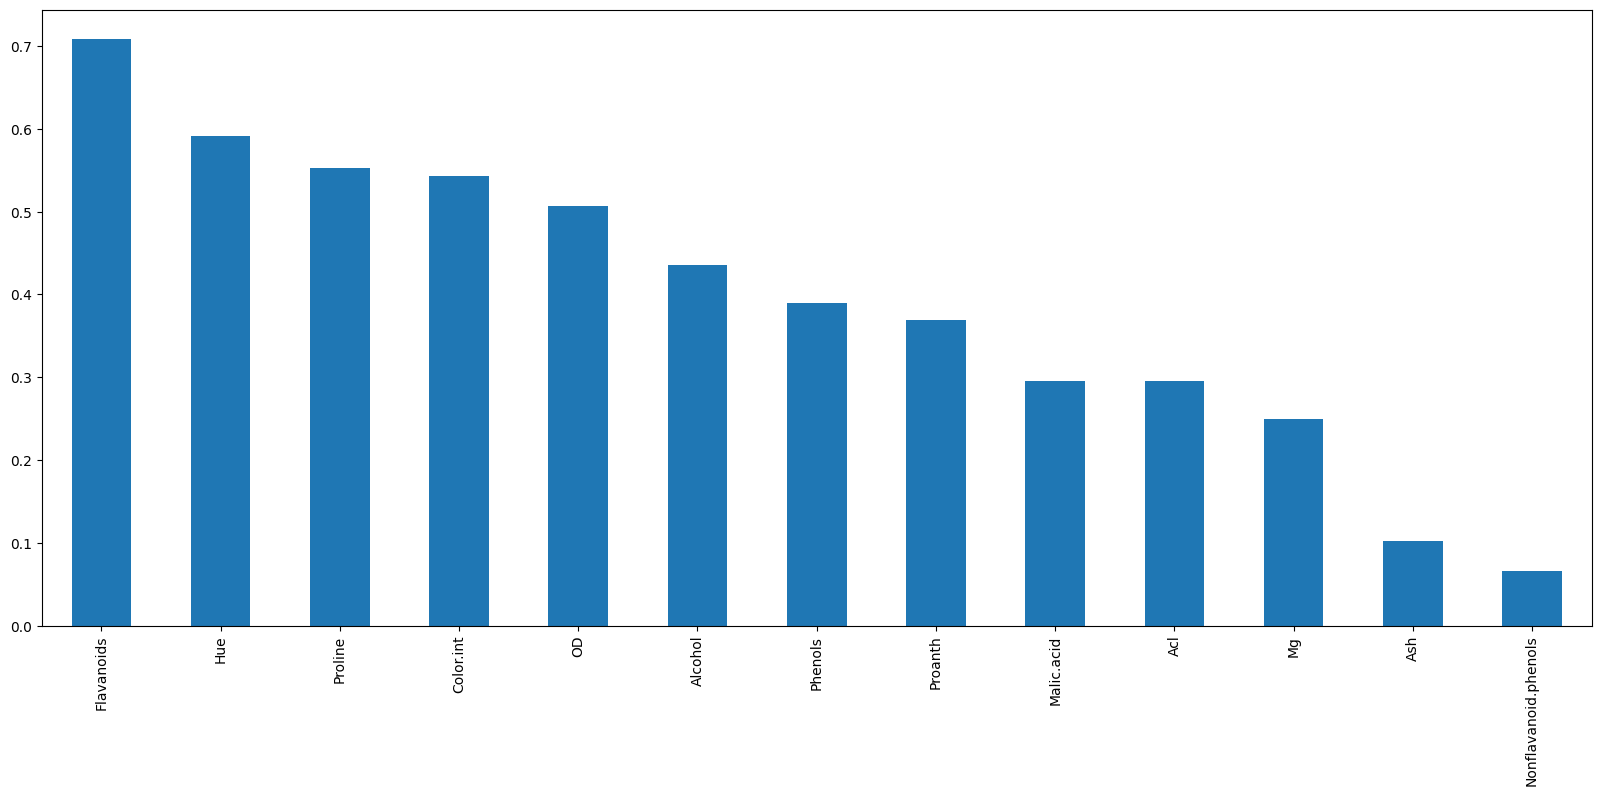

In [45]:
mutual_info.sort_values(ascending=False).plot.bar(figsize=(20,8))

In [46]:
from sklearn.feature_selection import SelectKBest

In [47]:
sel_five_col = SelectKBest(mutual_info_classif,k=5)
sel_five_col.fit(X_train,y_train)
X_train.columns[sel_five_col.get_support()]

Index(['Flavanoids', 'Color.int', 'Hue', 'OD', 'Proline'], dtype='str')

## Regression Probelm

In [48]:
from sklearn.feature_selection import mutual_info_regression

# make sure you fill null values otherwise its give you error.

In [ ]:
from sklearn.feature_selection import SelectPercentile

In [ ]:
selected_top_columns = SelectPercentile(mutual_info_regression, percentile=20)
selected_top_columns.fit(X_train.fillna(0), y_train)

In [ ]:
selected_top_columns.get_support()

In [ ]:
X_train.columns[selected_top_columns.get_support()]

## Anova Test

In [ ]:
from sklearn.feature_selection import f_classif
from sklearn.feature_selection import SelectKBest

selector = SelectKBest(score_func=f_classif, k=5)
X_new = selector.fit_transform(X, y)

## Forward Selection

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

sfs = SequentialFeatureSelector(
    model,
    n_features_to_select=3,
    direction="forward"
)

X_new = sfs.fit_transform(X,y)

## Backward Selection

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

sfs = SequentialFeatureSelector(
    model,
    n_features_to_select=3,
    direction="backward"
)

X_new = sfs.fit_transform(X, y)

## Stepwise Selection
Stepwise Selection is a combination of Forward Selection and Backward Elimination.

It adds features like forward selection
AND
It removes features if they become useless later

So it moves both forward and backward.

Problem with Forward:

Once you add a feature → you never remove it.

Problem with Backward:

Once you remove a feature → you never reconsider it.

Stepwise fixes this by allowing both actions.

## Recursive Feature Elimination

It is a wrapper method that:

Trains a model → ranks features → removes the weakest → repeats.

Unlike forward/backward which try combinations,
RFE uses model importance directly.



In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

rfe = RFE(model, n_features_to_select=3)
X_new = rfe.fit_transform(X, y)

Perfect 👌🔥
Now we’re entering **advanced feature selection techniques** — the ones actually used in real ML projects.

I’ll explain each one the same structured way:

* 🎯 What it is
* 🧠 Core intuition
* 🔁 How it works step-by-step
* ✅ When to use
* ⚠ Limitations
* 🆚 Why it’s different

---

# 🔹 A. BORUTA

## 🎯 What is Boruta?

Boruta is a **wrapper feature selection method built on Random Forest**.

It tries to answer:

> “Is this feature truly important, or just randomly useful?”

It selects **all relevant features**, not just minimal ones.

---

## 🧠 Core Intuition (Very Important 🔥)

Instead of asking:

> "Is this feature useful?"

Boruta asks:

> "Is this feature more useful than random noise?"

If yes → keep
If not → remove

---

## 🔁 How Boruta Works (Step-by-Step)

Suppose you have features:

X1, X2, X3

---

### Step 1️⃣ Create Shadow Features

For every feature:

* Shuffle its values randomly
* Add to dataset

Example:

X1 → Shadow_X1 (randomly shuffled)

Now dataset:

X1, X2, X3, Shadow_X1, Shadow_X2, Shadow_X3

---

### Step 2️⃣ Train Random Forest

Random Forest gives feature importance for all features.

---

### Step 3️⃣ Compare Real vs Shadow

If:

Importance(X1) > Max(Shadow importance)

→ X1 is truly important

If:

Importance(X2) ≤ Shadow

→ X2 is rejected

---

### Step 4️⃣ Repeat

Boruta runs multiple iterations for stability.

---

## 🎯 Why It’s Powerful

* Robust to noise
* Finds ALL relevant features
* Works well with nonlinear data

---

## ⚠ Limitations

* Slow (many RF trainings)
* Works mainly with tree-based models
* Heavy for very large datasets

---

## ✅ When to Use Boruta?

✔ When interpretability important
✔ When you want all relevant features
✔ When using Random Forest

---

# 🔹 B. SHAP-Based Feature Selection

## 🎯 What is SHAP?

SHAP = SHapley Additive exPlanations

Based on game theory.

It measures:

> “How much each feature contributes to each prediction?”

---

## 🧠 Core Intuition

Imagine prediction is a team effort.

Each feature is a player.

SHAP measures how much each player contributed to the final result.

---

## 🔁 How SHAP Selection Works

1️⃣ Train model (any model)
2️⃣ Compute SHAP values
3️⃣ Take average absolute SHAP value per feature
4️⃣ Rank features
5️⃣ Select top features

---

## 📊 Example

Suppose SHAP average values:

| Feature | Mean SHAP |
| ------- | --------- |
| X1      | 0.45      |
| X2      | 0.03      |
| X3      | 0.30      |

X2 has very low impact → remove it.

---

## 🎯 Why It’s Powerful

* Model-agnostic (works for any model)
* Captures non-linear effects
* Captures interactions
* Very interpretable

---

## ⚠ Limitations

* Computationally heavy
* Requires trained model
* Complex for beginners

---

## ✅ When to Use SHAP Selection?

✔ When explainability matters
✔ In production ML systems
✔ Complex models (XGBoost, deep models)

---

# 🔹 C. Permutation Importance

## 🎯 What is Permutation Importance?

It measures:

> “How much model performance drops if we destroy this feature?”

---

## 🧠 Core Intuition

If feature is important:

Shuffling it will damage model performance.

If not important:

Shuffling won’t change much.

---

## 🔁 Step-by-Step

1️⃣ Train model
2️⃣ Measure baseline accuracy
3️⃣ Shuffle feature X1
4️⃣ Measure new accuracy
5️⃣ Compute drop

Example:

Baseline = 90%
After shuffle X1 = 70%

Drop = 20% → Very important

---

## 🎯 Why It’s Powerful

* Model-agnostic
* Works for regression & classification
* Captures real performance impact

---

## ⚠ Limitations

* Slow for many features
* Correlated features can mislead
* Requires retraining or re-scoring many times

---

## 🆚 Compared to SHAP

| SHAP                  | Permutation               |
| --------------------- | ------------------------- |
| Measures contribution | Measures performance drop |
| More theoretical      | More practical            |
| Expensive             | Moderate                  |

---

# 🔹 D. Genetic Algorithms (GA)

## 🎯 What is GA Feature Selection?

Inspired by biological evolution.

It searches for the best feature subset using:

* Selection
* Crossover
* Mutation

---

## 🧠 Core Intuition

Imagine each feature subset is a "chromosome".

Example:

[1, 0, 1, 0, 1]

Means:
Use X1, X3, X5
Ignore X2, X4

---

## 🔁 How It Works

1️⃣ Generate random subsets
2️⃣ Train model → compute fitness (accuracy)
3️⃣ Select best subsets
4️⃣ Crossover (combine subsets)
5️⃣ Mutate randomly
6️⃣ Repeat for generations

Over time → best subset survives.

---

## 🎯 Why It’s Powerful

* Searches global solution
* Can escape greedy traps
* Good for complex feature interactions

---

## ⚠ Limitations

* Very computationally expensive
* Many hyperparameters
* Not common in standard ML pipelines

---

## ✅ When to Use GA?

✔ When feature space huge
✔ When interactions very complex
✔ Research/optimization problems

---

# 🔥 Comparison Summary

| Method      | Type           | Speed     | Good For        | Handles Nonlinear |
| ----------- | -------------- | --------- | --------------- | ----------------- |
| Boruta      | Wrapper        | Slow      | Tree models     | ✅ Yes             |
| SHAP        | Embedded-like  | Slow      | Explainability  | ✅ Yes             |
| Permutation | Model-agnostic | Medium    | True importance | ✅ Yes             |
| Genetic     | Metaheuristic  | Very Slow | Complex search  | ✅ Yes             |

---

# 🚀 Real-World Insight

In modern ML:

* Use **Permutation Importance** for quick evaluation
* Use **SHAP** for explainability
* Use **Boruta** when using Random Forest
* Use **Genetic Algorithms** only for research/heavy optimization

---

# 🎯 Final Big Picture

Traditional methods:

* Chi-square
* ANOVA
* Lasso

Advanced methods:

* Boruta (noise comparison)
* SHAP (game theory contribution)
* Permutation (performance drop)
* Genetic (evolution search)

They are more powerful because they:

* Capture non-linear patterns
* Use model performance directly
* Work well in modern ML

---



## Boruta

In [ ]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

# Define model
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Initialize Boruta
boruta = BorutaPy(
    estimator=rf,
    n_estimators='auto',
    verbose=2,
    random_state=42
)

# Fit
boruta.fit(X.values, y.values)

# Selected features
selected_features = X.columns[boruta.support_]
print(selected_features)

## shap

In [ ]:
import shap
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X, y)

# Create explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# Mean absolute SHAP value per feature
import numpy as np
mean_shap = np.abs(shap_values[1]).mean(axis=0)

# Rank features
feature_importance = dict(zip(X.columns, mean_shap))

sorted_features = sorted(feature_importance.items(), 
                         key=lambda x: x[1], 
                         reverse=True)

print(sorted_features)

## Permutation Importance

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X, y)

result = permutation_importance(
    model,
    X,
    y,
    n_repeats=10,
    random_state=42
)

importance = result.importances_mean

feature_importance = dict(zip(X.columns, importance))

sorted_features = sorted(feature_importance.items(),
                         key=lambda x: x[1],
                         reverse=True)

print(sorted_features)

## Genetic Algorithm

In [ ]:
from genetic_selection import GeneticSelectionCV
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

selector = GeneticSelectionCV(
    model,
    cv=5,
    verbose=1,
    scoring="accuracy",
    n_population=50,
    n_generations=20,
    mutation_proba=0.2,
    crossover_proba=0.5,
    n_jobs=-1
)

selector.fit(X, y)

selected_features = X.columns[selector.support_]
print(selected_features)